# Online vs. Batch Processing

This notebook compares three ways to run Fast-BOCPD:

1. Raw ``BOCPD.update`` calls (full control, minimal latency).
2. ``BOCPD.batch_update`` for high-throughput offline processing.
3. ``OnlineChangeDetector`` which wraps ``BOCPD`` with debounced alert logic.

We'll also animate a streaming scenario to visualise how changepoint
probabilities evolve sample by sample.


## 0. Environment setup


In [1]:

import sys
from pathlib import Path

CWD = Path.cwd()
REPO_ROOT = CWD if (CWD / "fast_bocpd").exists() else CWD.parent
EXAMPLES_DIR = REPO_ROOT / "examples"
sys.path.append(str(REPO_ROOT))
sys.path.append(str(EXAMPLES_DIR))
print(f"Using repo root: {REPO_ROOT}")


Using repo root: /home/tiaan/Projects/Fast_BOCPD


## 1. Imports and helpers


In [2]:

import time
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from fast_bocpd import BOCPD, ConstantHazard, GaussianNIG
from fast_bocpd.utils import OnlineChangeDetector

from _helpers import generate_piecewise_gaussian, plot_series_with_cp


## 2. Synthetic data

We'll use four regimes of different mean values. ``changepoints`` contains
the ground-truth boundaries so we can compare detections.


In [3]:

df, changepoints = generate_piecewise_gaussian(
    lengths=[120, 150, 80, 130],
    means=[0.0, 1.2, -0.3, 0.7],
    sigma=0.2,
    seed=21,
)
df.head()


,t,value,true_mean
0,0,-0.010393,0.0
1,1,-0.022239,0.0
2,2,0.208359,0.0
3,3,-0.251348,0.0
4,4,0.149078,0.0


## 3. Configure the core detector


In [4]:

obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=0.05, beta0=0.01)
hazard = ConstantHazard(lambda_=140)
max_run_length = 500


## 4. Streaming with ``BOCPD.update``

This loop represents a true online scenario. We store changepoint probabilities
and the MAP run length for later visualisation.


In [5]:

stream_detector = BOCPD(obs_model, hazard, max_run_length=max_run_length)
cp_probs = []
map_run_lengths = []
start = time.perf_counter()
for value in df["value"]:
    posterior, cp_prob = stream_detector.update(float(value))
    cp_probs.append(cp_prob)
    map_run_lengths.append(int(np.argmax(posterior)))
stream_time = time.perf_counter() - start
df["cp_prob_stream"] = cp_probs
df["map_r_stream"] = map_run_lengths
stream_time


0.013531643897294998

## 5. Batch processing with ``BOCPD.batch_update``

For offline or replay scenarios we can feed the entire NumPy array in one call.
This eliminates per-sample Python overhead and is typically 30–50% faster.


In [6]:

batch_detector = BOCPD(obs_model, hazard, max_run_length=max_run_length)
start = time.perf_counter()
cp_probs_batch = batch_detector.batch_update(df["value"].to_numpy())
batch_time = time.perf_counter() - start
batch_time


0.009810823015868664

In [7]:

print(f"Streaming loop: {stream_time*1e3:.1f} ms")
print(f"Batch update:  {batch_time*1e3:.1f} ms")
print(f"Speedup:       {stream_time / batch_time:.2f}x")


Streaming loop: 13.5 ms
Batch update:  9.8 ms
Speedup:       1.38x


## 6. OnlineChangeDetector convenience wrapper

``OnlineChangeDetector`` encapsulates a common alerting pattern: trigger when
``P(r_t = 0)`` crosses a threshold while obeying cooldown/drop rules. Use it
when you want a ready-made debounced signal; stick with raw ``BOCPD`` when you
need custom logic.


In [8]:

ocd = OnlineChangeDetector(
    stream_detector,
    min_cp_prob=0.35,
    reset_r=2,
    cooldown=15,
)

changepoint_events = []
for idx, value in enumerate(df["value"]):
    event = ocd.update(float(value), metadata={"index": idx})
    if event is not None:
        changepoint_events.append(event.index)
changepoint_events[:5]


[1, 120, 270, 350, 351]

## 7. Visual comparison

The figure overlays the streaming probabilities and the detections emitted by
``OnlineChangeDetector``.


In [9]:

fig = plot_series_with_cp(
    df.rename(columns={"cp_prob_stream": "cp_prob"}),
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=changepoints,
    title="Streaming BOCPD vs ground truth",
)
for event_idx in changepoint_events:
    fig.add_annotation(
        x=df.loc[event_idx, "t"],
        y=df.loc[event_idx, "value"],
        text="Alert",
        arrowhead=2,
        ay=-40,
        font=dict(color="crimson"),
    )
fig


## 8. Animated streaming view

The animation below replays the series sample by sample. Orange markers indicate
``OnlineChangeDetector`` alerts.


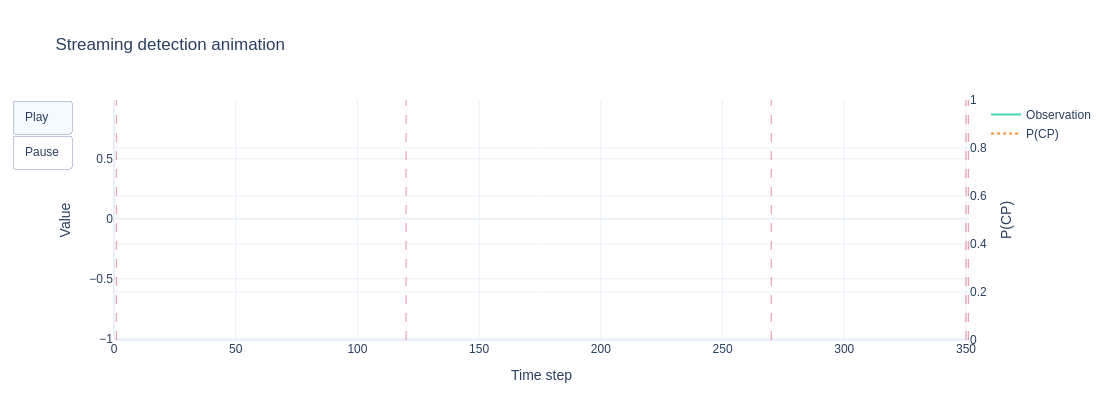

In [10]:

num_points = len(df)
frame_step = 10  # only render every Nth point for lighter notebook

frames = []
for idx in range(frame_step, num_points + 1, frame_step):
    subset = df.iloc[:idx]
    frame = go.Frame(
        data=[
            go.Scatter(x=subset["t"], y=subset["value"], mode="lines", name="Observation"),
            go.Scatter(x=subset["t"], y=subset["cp_prob_stream"], mode="lines", name="P(CP)", yaxis="y2"),
        ],
        name=str(idx),
    )
    frames.append(frame)

anim_fig = go.Figure(
    data=[
        go.Scatter(x=df.iloc[:1]["t"], y=df.iloc[:1]["value"], mode="lines", name="Observation", line=dict(color="#40d6b9", width=2)),
        go.Scatter(x=df.iloc[:1]["t"], y=df.iloc[:1]["cp_prob_stream"], mode="lines", name="P(CP)", line=dict(color="#F28E2B", width=2, dash="dot"), yaxis="y2"),
    ],
    layout=go.Layout(
        title="Streaming detection animation",
        xaxis=dict(title="Time step"),
        yaxis=dict(title="Value"),
        yaxis2=dict(title="P(CP)", overlaying="y", side="right", range=[0, 1]),
        template="plotly_white",
        updatemenus=[
            {
                "type": "buttons",
                "buttons": [
                    {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 200, "redraw": True}, "fromcurrent": True}]},
                    {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0}, "mode": "immediate", "transition": {"duration": 0}}]},
                ],
            }
        ],
        height=420,
    ),
    frames=frames,
)

for event_idx in changepoint_events:
    anim_fig.add_vline(x=df.loc[event_idx, "t"], line=dict(color="crimson", dash="dash", width=1.2), opacity=0.4)

anim_fig


## When to use what?

- **``BOCPD.update``** – best for integrating into custom streaming pipelines
  where you control the alerting rules.
- **``OnlineChangeDetector``** – drop-in helper when you want debounced alerts
  based on probability thresholds and cooldowns.
- **``batch_update``** – use when you are replaying historical data or running
  offline evaluations/benchmarks; it minimises Python overhead by letting the
  C core process contiguous arrays.

Proceed to ``03_understanding_outputs.ipynb`` to dive deeper into the
run-length posterior and interpretation techniques.
